In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

In [4]:
DATA_DIR = '../../Data/splitting_data/used'
splitting_file = os.path.join(DATA_DIR, 'ACl_FILTERED_DATA_04.csv')

In [5]:
splitting_data = pd.read_csv(splitting_file)

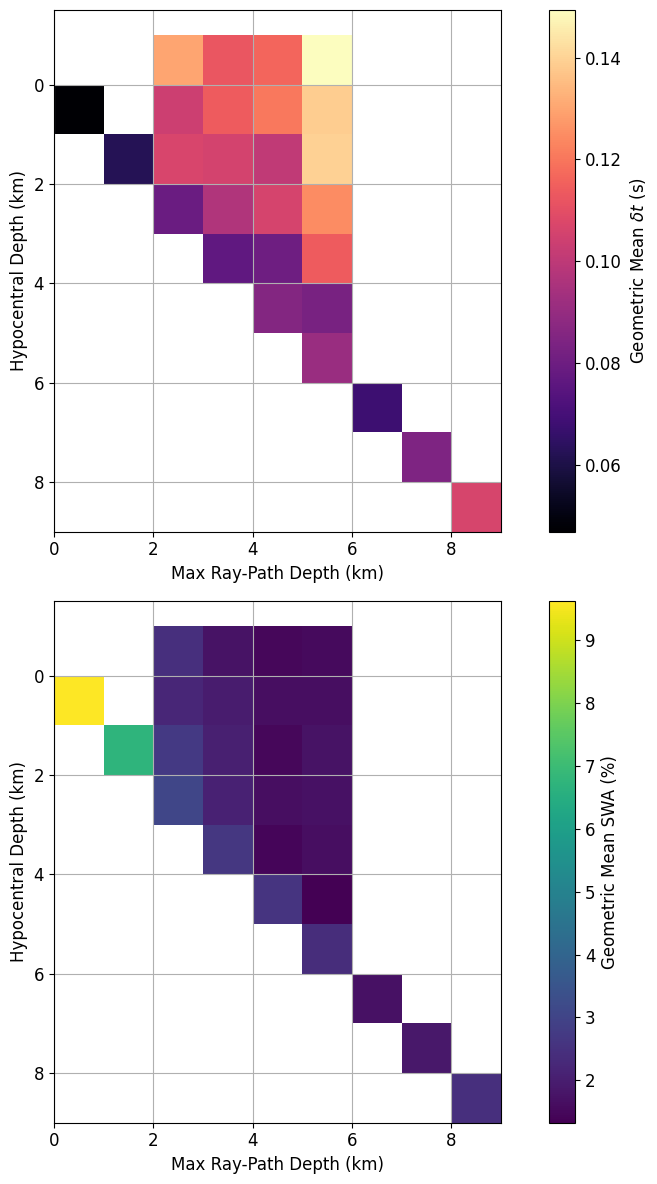

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gmean

# Plot styling (avoid forcing Helvetica; keep default sans-serif stack).
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "font.family": "sans-serif",
})


# Define 1 km grid bins.
bin_size = 1
x_bins = np.arange(-1, 9 + bin_size, bin_size)
y_bins = np.arange(-1, 9 + bin_size, bin_size)

# Assign each observation to grid indices.
x_inds = np.digitize(splitting_data["max_ray_depth_km"], x_bins) - 1
y_inds = np.digitize(splitting_data["depthkm"], y_bins) - 1

# Allocate output grids.
nrows, ncols = len(y_bins) - 1, len(x_bins) - 1
geo_mean_tlag_grid = np.full((nrows, ncols), np.nan)
geo_mean_swa_grid = np.full((nrows, ncols), np.nan)
count_grid = np.zeros((nrows, ncols), dtype=int)

# Fill each cell with geometric means of valid (>0, non-NaN) values.
for i in range(ncols):
    for j in range(nrows):
        mask = (x_inds == i) & (y_inds == j)
        count_grid[j, i] = np.sum(mask)

        if not np.any(mask):
            continue

        tlag_values = splitting_data["tlag"][mask]
        swa_values = splitting_data["SWA_source_to_station"][mask]

        tlag_valid = tlag_values[~np.isnan(tlag_values) & (tlag_values > 0)]
        swa_valid = swa_values[~np.isnan(swa_values) & (swa_values > 0)]

        if len(tlag_valid) > 0:
            geo_mean_tlag_grid[j, i] = gmean(tlag_valid)
        if len(swa_valid) > 0:
            geo_mean_swa_grid[j, i] = gmean(swa_valid)


# Shared axis settings.
x_min, x_max = 0, 9
y_min, y_max = -1.5, 9

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

plot_configs = [
    (geo_mean_tlag_grid, "magma", r"Geometric Mean $\delta t$ (s)"),
    (geo_mean_swa_grid, "viridis", "Geometric Mean SWA (%)"),
]

for ax, (grid_data, cmap, cbar_label) in zip(axes, plot_configs):
    mesh = ax.pcolormesh(x_bins, y_bins, grid_data, cmap=cmap, shading="auto")
    cbar = plt.colorbar(mesh, ax=ax)
    cbar.set_label(cbar_label, fontsize=12)
    cbar.ax.tick_params(labelsize=12)

    ax.set_xlabel("Max Ray-Path Depth (km)", fontsize=12)
    ax.set_ylabel("Hypocentral Depth (km)", fontsize=12)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.grid(True)

plt.tight_layout()
# plt.show()
plt.savefig("Figure_12.png", dpi=150, bbox_inches="tight")